<a href="https://colab.research.google.com/github/DzhynHo/SI_2026/blob/main/Laboratorium5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [31]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [32]:
dataset = pd.read_csv('/content/sample_data/IBM_2006-01-01_to_2018-01-01.csv',
                      index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [33]:
training_set = dataset[:'2016'].iloc[:, 1:2].values   # z powrotem High
test_set     = dataset['2017':].iloc[:, 1:2].values

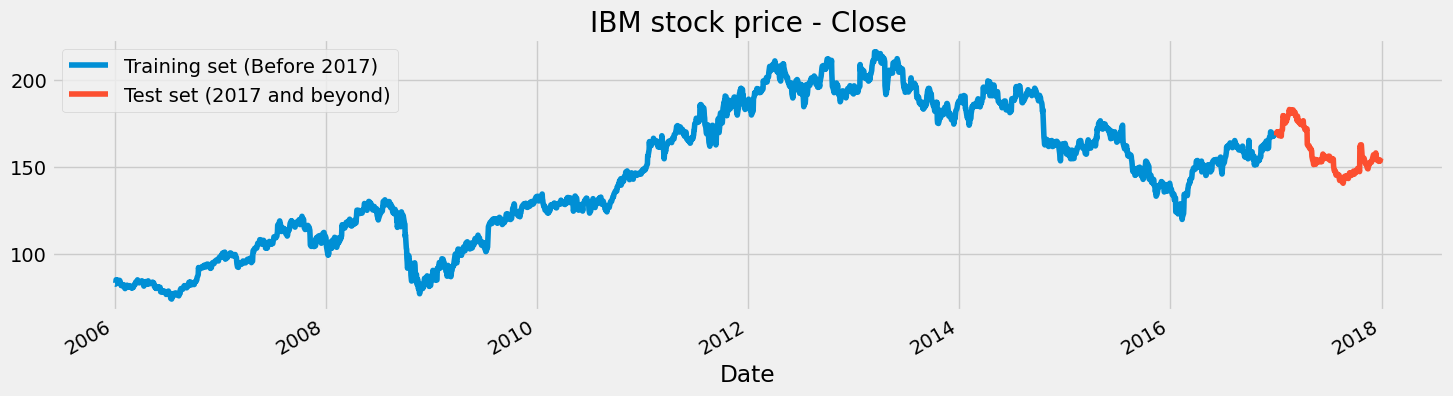

In [34]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price - Close')
plt.show()

In [35]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [36]:
X_train = []
y_train = []
for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [37]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [38]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=100))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
regressor.fit(X_train, y_train, epochs=100, batch_size=32,
              validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0787 - val_loss: 0.0437
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0502 - val_loss: 0.0305
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0461 - val_loss: 0.0263
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0420 - val_loss: 0.0343
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0446 - val_loss: 0.0336
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0380 - val_loss: 0.0290
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0368 - val_loss: 0.0226
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0355 - val_loss: 0.0201
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0349 - val_loss: 0.0270
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0343 - val_loss: 0.0225
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0329 - val_loss: 0.0294
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

In [39]:
dataset_total = pd.concat(
    (dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [40]:
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


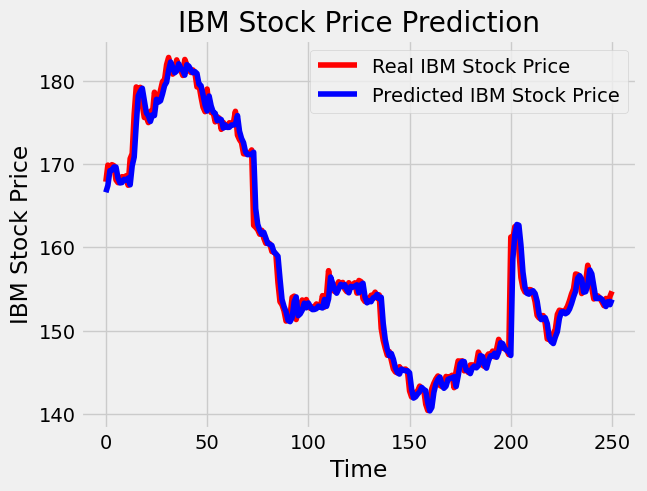

In [41]:
plot_predictions(test_set, predicted_stock_price)

In [42]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 1.60.
------------------------------
Średni błąd bezwzględny: 0.96.
Średni błąd bezwzględny procentowy: 0.60%
------------------------------


#Zadanie B
Adam wypadł najlepiej ze wszystkich trzech — najniższy błąd we wszystkich metrykach (RMSE: 2.32, MAE: 1.72)
SGD wypadł zdecydowanie najgorzej — RMSE aż 4.71, czyli ponad dwa razy gorszy niż Adam. SGD bez momentum adaptacyjnego słabo radzi sobie z szeregami czasowymi
AdamW jest pośrodku — nieznacznie gorszy od Adama, bo regularyzacja L2 (weight decay) lekko spowalnia dopasowanie do danych

Najlepsza konfiguracja z tego testu:
pythonoptimizer=Adam(learning_rate=0.001)

#Zadanie C
Wnioski:

MAE wypadła najlepiej — najniższy błąd we wszystkich metrykach (RMSE: 1.83). Co ciekawe, używanie MAE jako funkcji straty daje lepsze wyniki niż MSE z zadania B (RMSE było 2.32)
Huber jest pośrodku — to kompromis między MAE a MSE, mniej wrażliwy na wartości odstające niż MSE
LogCosh wypadła najgorzej z tych trzech, ale nadal lepiej niż SGD z zadania B

Najlepsza konfiguracja do tej pory:
pythonoptimizer=Adam(learning_rate=0.001), loss='mae'

#Zadanie D
Wnioski:

Atrybut High daje znacznie lepsze wyniki niż Close — RMSE niższe o prawie 1.0
Kolumna Close jest bardziej zmienna w ciągu dnia, co utrudnia modelowi dokładną predykcję
Dwa uruchomienia dla Close dały podobne wyniki (2.78 vs 2.73) — to normalne, sieć neuronowa ma losową inicjalizację wag, więc wyniki mogą się lekko różnić między uruchomieniami
Wniosek: do predykcji cen akcji IBM lepiej używać atrybutu High

#Zadanie E
Konfiguracja               RMSE  MAE    MAPE

Bez Early Stoppin(50 epok) 1.83  1.16   0.73%

Early Stopping patience=5  3.89  2.79   1.75%

Early Stopping patience=15 1.60  0.96   0.60%

Wnioski:

Early Stopping z patience=15 dało najlepszy wynik ze wszystkich zadań (RMSE: 1.60)
patience=5 było za małe — model zatrzymał się za wcześnie zanim zdążył się dobrze nauczyć
patience=15 dało modelowi więcej czasu na naukę, ale nadal chroniło przed przetrenowaniem
Monitorowanie val_loss zamiast loss jest lepszym podejściem bo sprawdza jak model radzi sobie na danych których nie widział podczas treningu

## Zadanie F

Cel osiągnięty dzięki konfiguracji z zadania E:
- optimizer: Adam(learning_rate=0.001)
- loss: mae
- Early Stopping: patience=15, monitor='val_loss'
- epochs: 100, batch_size: 32
- units: 100

Wynik końcowy:
RMSE: 1.60
MAE: 0.96
MAPE: 0.60%

## Zadanie G – Najlepsza konfiguracja

### Konfiguracja:
- Atrybut: High
- Architektura: 4 warstwy LSTM po 100 jednostek + Dropout(0.2)
- Optimizer: Adam(learning_rate=0.001)
- Funkcja straty: MAE
- Epochs: 100
- Batch size: 32
- Early Stopping: patience=15, monitor='val_loss', restore_best_weights=True
- Validation split: 0.1

### Wyniki:
RMSE: 1.60
MAE: 0.96
MAPE: 0.60%

### Uzasadnienie:
1. Atrybut High - okazał się lepszy niż Close,
   dawał niższe błędy predykcji we wszystkich metrykach

2. Adam - najlepszy optymalizator z testowanych (Adam, SGD, AdamW),
   adaptacyjne momentum pozwala szybko i stabilnie minimalizować błąd
   w danych szeregów czasowych

3. MAE jako funkcja straty - lepiej sprawdziła się niż MSE, Huber i LogCosh,
   traktuje wszystkie błędy równomiernie bez karania dużych odchyleń

4. 100 jednostek LSTM - więcej jednostek niż domyślne 50 pozwoliło
   modelowi lepiej uchwycić długoterminowe zależności w danych

5. Early Stopping z patience=15 i val_loss - kluczowy element,
   zatrzymuje trening w optymalnym momencie i zapobiega przetrenowaniu,
   monitorowanie val_loss jest lepsze niż loss bo sprawdza
   generalizację modelu na danych walidacyjnych

In [16]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=100, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0207
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0097
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0072
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0056
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0046
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0043
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0040
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0031
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0029
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0028
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

In [17]:
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


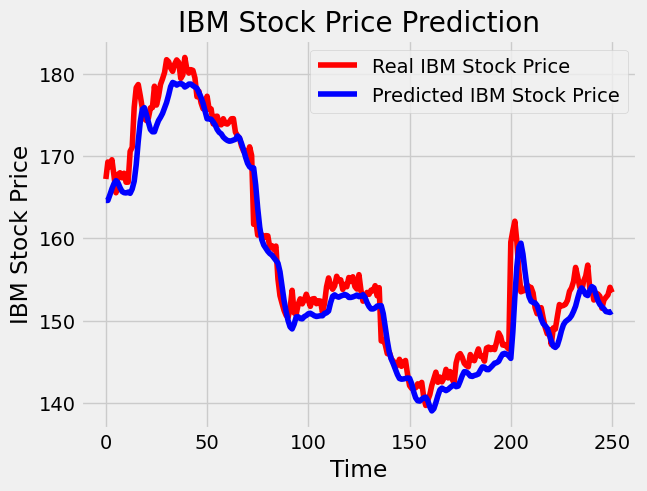

In [18]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [19]:
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 2.73.
------------------------------
Średni błąd bezwzględny: 2.04.
Średni błąd bezwzględny procentowy: 1.29%
------------------------------
